# 2. Tiesinė regresija (privalomas baseline)

**Failas:** `winequality/baselines.py` → `linear_pipeline`  
**Pirminis apdorojimas:** `winequality/transform.py` → `Log1pStandardScaler`

Tai vienas tiesinis neuronas (LD1): standartizuotų požymių linijinė kombinacija.
Rinkinio autoriai (Cortez ir kt., 2009) gavo MAE ≈ 0,50 / 0,59; tai mūsų „stop“ taisyklės riba.


## Formulės

Asimetriškiems požymiams \(j \in S\) (cukrus, chloridai, SO₂, sulfatai):

\[
x'_j = \ln(1 + x_j),\qquad
z_j = \frac{x'_j - \mu_j}{\sigma_j}
\]

\(\mu_j,\sigma_j\) skaičiuojami **tik mokymo aibėje**. Prognozė:

\[
f(\mathbf{z}) = \mathbf{w}^\top \mathbf{z} + b
\]

Svoriai \(w,b\) gaunami mažiausių kvadratų metodu (sklearn `LinearRegression` = OLS).


In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

here = Path.cwd().resolve()
root = here if (here / "winequality").exists() else here.parent
sys.path.insert(0, str(root))
sys.path.insert(0, str(root / "notebooks"))

from nb_pagalba import paruošti, metrikos_lentele, artefaktas
from winequality.config import FEATURE_NAMES, SPLIT_SEED

KIND = "red"  # pakeiskite į "white", jei norite balto vyno
duom = paruošti(KIND)
X_tr, y_tr, X_te, y_te = duom["X_tr"], duom["y_tr"], duom["X_te"], duom["y_te"]
print(f"{KIND}: mokymo n={duom['n_train']}, testo n={duom['n_test']}, sėkla={SPLIT_SEED}")
print("Požymiai:", FEATURE_NAMES)


red: mokymo n=1279, testo n=320, sėkla=0
Požymiai: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## Mokymas ir formulės sutikrinimas


In [2]:
from winequality.baselines import linear_pipeline
from winequality.transform import Log1pStandardScaler

vamzdis = linear_pipeline()
vamzdis.fit(X_tr, y_tr)

prep = vamzdis.named_steps["prep"]
lin = vamzdis.named_steps["lin"]
z_te = prep.transform(X_te)

# f(z) = wᵀz + b  — rankinis kelias
f_formule = z_te @ lin.coef_ + lin.intercept_
f_sklearn = vamzdis.predict(X_te)
print("max |formulė − sklearn| =", np.max(np.abs(f_formule - f_sklearn)))

koef = pd.Series(lin.coef_, index=FEATURE_NAMES).sort_values()
display(koef.to_frame("w_j").T.round(3))
print("poslinkis b =", round(float(lin.intercept_), 3))


max |formulė − sklearn| = 0.0


,volatile acidity,total sulfur dioxide,pH,chlorides,citric acid,density,residual sugar,fixed acidity,free sulfur dioxide,sulphates,alcohol
w_j,-0.181,-0.136,-0.087,-0.074,-0.056,-0.016,0.006,0.053,0.105,0.163,0.299


poslinkis b = 5.634


## Testo metrikos ir koeficientų interpretacija


,modelis,MAE,MAE (apvalinta),Acc_0.5,Acc_1.0,κ_w,makro-F1
0,tiesinė regresija,0.4908,0.4125,0.6219,0.875,0.5412,0.5077


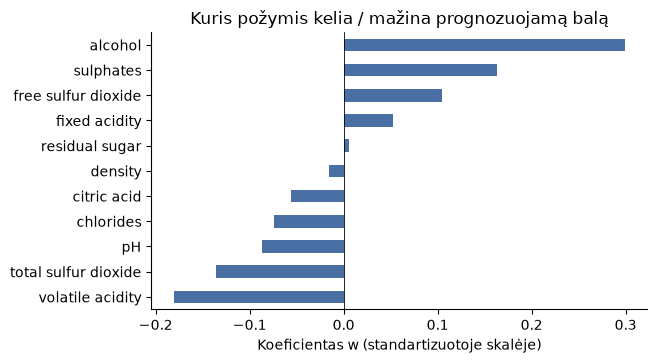

In [3]:
lentele = metrikos_lentele(y_te, f_sklearn, "tiesinė regresija")
display(lentele.round(4))

fig, ax = plt.subplots(figsize=(6.4, 3.6))
koef.plot.barh(ax=ax, color="#4a6fa5")
ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("Koeficientas w (standartizuotoje skalėje)")
ax.set_title("Kuris požymis kelia / mažina prognozuojamą balą")
ax.spines[["top", "right"]].set_visible(False)
plt.show()


## Ką stebėti

- Alkoholis paprastai turi **teigiamą** \(w\), lakiosios rūgštys — **neigiamą** (enologinė teorija).
- MAE turi būti aiškiai mažesnis už vidurkio baseline (~0,49 raudonam, ~0,57 baltam šiame skaidyme).
- Modelis negali modeliuoti požymių sąveikų (pvz., alkoholis × lakiosios rūgštys) — todėl SVR/RF turi erdvės jį pranokti.
